## EDA

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


In [5]:
X_train = pd.read_csv("../data/raw/x_train.csv")
y_train = pd.read_csv("../data/raw/y_train.csv")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (418595, 47)
y_train shape: (418595, 2)


In [8]:
X_train.head()

,ID,DATE,STOCK,INDUSTRY,INDUSTRY_GROUP,SECTOR,SUB_INDUSTRY,RET_1,VOLUME_1,RET_2,VOLUME_2,RET_3,VOLUME_3,RET_4,VOLUME_4,RET_5,VOLUME_5,RET_6,VOLUME_6,RET_7,VOLUME_7,RET_8,VOLUME_8,RET_9,VOLUME_9,RET_10,VOLUME_10,RET_11,VOLUME_11,RET_12,VOLUME_12,RET_13,VOLUME_13,RET_14,VOLUME_14,RET_15,VOLUME_15,RET_16,VOLUME_16,RET_17,VOLUME_17,RET_18,VOLUME_18,RET_19,VOLUME_19,RET_20,VOLUME_20
0,0,0,2,18,5,3,44,-0.015748,0.147931,-0.015504,0.179183,0.010972,0.033832,-0.014672,-0.362868,0.016483,-0.972920,0.014331,0.590810,-0.017215,0.557246,-0.018433,0.453590,0.134146,8.580442,0.182287,3.427303,0.013570,-0.328418,0.030108,-0.816436,0.027624,-0.244636,-0.049370,-2.042624,-0.028571,-0.369605,0.059459,0.630899,0.003254,-0.379412,0.008752,-0.110597,-0.012959,0.174521,-0.002155,-0.000937
1,1,0,3,43,15,6,104,0.003984,NaN,-0.090580,NaN,0.018826,NaN,-0.025540,NaN,-0.038062,NaN,-0.006873,NaN,-0.026756,NaN,0.023973,NaN,0.158731,NaN,0.045642,NaN,-0.008230,NaN,-0.028000,NaN,-0.019608,NaN,-0.052044,NaN,-0.004073,NaN,0.015413,NaN,0.003774,NaN,-0.018518,NaN,-0.028777,NaN,-0.034722,NaN
2,2,0,4,57,20,8,142,0.000440,-0.096282,-0.058896,0.084771,-0.009042,-0.298777,0.024852,-0.157421,0.009354,0.091455,0.027522,-0.405978,-0.023047,-0.389777,-0.002979,-0.701838,-0.006342,-0.229531,0.055803,0.543460,-0.012781,-0.121126,0.028093,-0.187444,-0.009426,-0.081783,-0.002686,-0.356711,-0.007552,-0.336773,0.008964,-0.010336,-0.017612,-0.354333,-0.006562,-0.519391,-0.012101,-0.356157,-0.006867,-0.308868
3,3,0,8,1,1,1,2,0.031298,-0.429540,0.007756,-0.089919,-0.004632,-0.639737,-0.019677,-0.940163,0.003544,-0.882464,-0.002021,-0.113951,-0.043962,-0.395345,-0.004329,-0.765754,0.014146,-0.593888,-0.021946,0.588171,0.007693,-0.427358,0.007264,-0.540519,-0.010067,-0.839232,0.000479,-2.144763,0.021057,-0.431029,-0.031769,0.012105,0.033824,-0.290178,-0.001468,-0.663834,-0.013520,-0.562126,-0.036745,-0.631458
4,4,0,14,36,12,5,92,0.027273,-0.847155,-0.039302,-0.943033,0.000000,-1.180629,0.000000,-1.313896,0.022321,-1.204398,0.018182,-0.879172,-0.026549,-0.858613,-0.017391,-0.029690,-0.008621,-1.022991,0.022026,-0.387114,-0.008734,-0.288180,-0.004348,-0.115091,-0.041667,0.271702,0.095891,18.894266,-0.026667,0.803608,-0.038461,-0.277083,-0.012659,0.139086,0.004237,-0.017547,0.004256,0.579510,-0.040817,0.802806


In [9]:
y_train.head()

,ID,RET
0,0,True
1,1,True
2,2,False
3,3,False
4,4,False


In [10]:
print("Colonnes X_train :", X_train.columns.tolist())
print("\nColonnes y_train :", y_train.columns.tolist())


Colonnes X_train : ['ID', 'DATE', 'STOCK', 'INDUSTRY', 'INDUSTRY_GROUP', 'SECTOR', 'SUB_INDUSTRY', 'RET_1', 'VOLUME_1', 'RET_2', 'VOLUME_2', 'RET_3', 'VOLUME_3', 'RET_4', 'VOLUME_4', 'RET_5', 'VOLUME_5', 'RET_6', 'VOLUME_6', 'RET_7', 'VOLUME_7', 'RET_8', 'VOLUME_8', 'RET_9', 'VOLUME_9', 'RET_10', 'VOLUME_10', 'RET_11', 'VOLUME_11', 'RET_12', 'VOLUME_12', 'RET_13', 'VOLUME_13', 'RET_14', 'VOLUME_14', 'RET_15', 'VOLUME_15', 'RET_16', 'VOLUME_16', 'RET_17', 'VOLUME_17', 'RET_18', 'VOLUME_18', 'RET_19', 'VOLUME_19', 'RET_20', 'VOLUME_20']

Colonnes y_train : ['ID', 'RET']


In [ ]:
X_train.dtypes.value_counts()   # verif des types 

float64    40
int64       7
Name: count, dtype: int64

In [ ]:
X_train.isna().mean().sort_values(ascending=False).head(10) #verif des NAN (les 10 colonnes avec le plus de NAN)


VOLUME_6     0.178488
VOLUME_5     0.178437
VOLUME_8     0.176538
VOLUME_7     0.176431
VOLUME_10    0.175122
VOLUME_9     0.175105
VOLUME_11    0.172064
VOLUME_4     0.169608
VOLUME_20    0.162107
VOLUME_3     0.162016
dtype: float64

- The dataset is well structured with a clear separation between identifiers, categorical stock descriptors & numerical time series features 
- Missing values are mainly concentrated in volume related features  which will require appropriate handling during preprocessing step...

## EDA FINANCIAL : RET ANALYSIS

- We re gonna try to see whether the increases & decreases are balanced or biased

In [14]:
df = X_train.merge(y_train, on="ID", how="inner")   # jointure  X / y pour securite 

print("Merged dataset shape:", df.shape)


Merged dataset shape: (418595, 48)


In [15]:
df["RET"].value_counts()    # distribution of the  target : rte

RET
False    209749
True     208846
Name: count, dtype: int64

In [16]:
df["RET"].value_counts(normalize=True) # en %

RET
False    0.501079
True     0.498921
Name: proportion, dtype: float64

- we can see that the target variable is perfectly balanced between positive and negative residual returns...meaning accuracy is a valide metric 
- each performance above 50% is usable 

(array([0, 1]), [Text(0, 0, 'False'), Text(1, 0, 'True')])

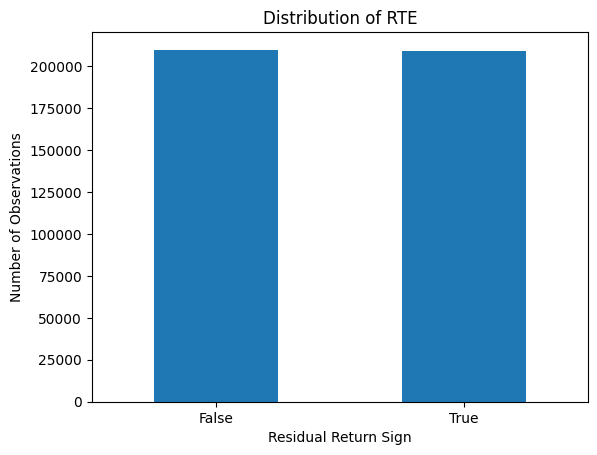

In [25]:
df["RET"].value_counts().plot(kind="bar")
plt.title("Distribution of RTE")
plt.xlabel("Residual Return Sign")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)

-  upward and downward stock movements occur with similar frequency which is consistent with a competitive financial market...

## Link between the Past and the Present 

- we wanna know if residual returns contain information about the next day residual return or not 

In [26]:
df.groupby("RET")["RET_1"].describe() # statist. of RET_1 conditionnel to the target


,count,mean,std,min,25%,50%,75%,max
RET,,,,,,,,
False,208576.0,0.001909,0.031749,-0.732431,-0.010832,0.000849,0.013580,1.422681
True,207660.0,0.000854,0.030856,-0.845324,-0.011110,0.000420,0.012346,1.444990


- the distribution of the previous day residual return i.e RET_1  is similar regardless of the next day return sign
- this suggests that simple one day momentum is weak and that RET_1 alone does not provide strong directional information... wich is normal in finance

- lets see if the distribution of RET_1 visually is different across the targets or not ...

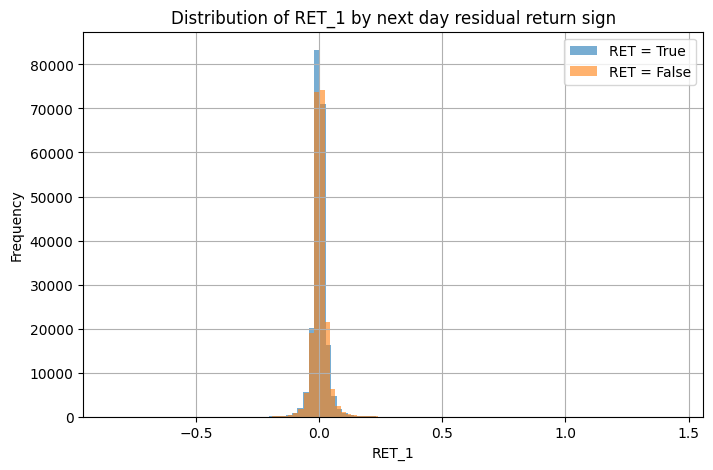

In [ ]:
plt.figure(figsize=(8, 5))
df[df["RET"] == True]["RET_1"].hist(bins=100, alpha=0.6, label="RET = True")
df[df["RET"] == False]["RET_1"].hist(bins=100, alpha=0.6, label="RET = False")
plt.legend()
plt.title("Distribution of RET_1 by next day residual return sign")
plt.xlabel("RET_1")
plt.ylabel("Frequency")

- as we can see there is no clear separation between the 2 classes based on RET_1 alone 
- simple one day momentum or reversal effects are extremely weak and not exploitable " on dit que le marché est quasi efficient à l horizon 1 jour" 

## - let s see if momentum or volatility contain more information than a single day return or no 

-  vocab: 
    - Momentum : if a stock went up yesterday it tends to go up again today --> Continuite du mouvement
    - Reversal : If a stock went up yesterday  it tends to go down today --< Retour vers la moyenne

In [28]:
df["RET_mean_5"] = df[[f"RET_{i}" for i in range(1, 6)]].mean(axis=1)   # we creat a  short term momentum signal 
df.groupby("RET")["RET_mean_5"].describe() # stat


,count,mean,std,min,25%,50%,75%,max
RET,,,,,,,,
False,208627.0,0.000989,0.013480,-0.224653,-0.004621,0.000783,0.006377,0.331250
True,207712.0,0.000684,0.013343,-0.253899,-0.004681,0.000591,0.005956,0.604759


- aggregating past returns over multiple days slightly stabilizes the signal but does not create a strong directional bias which is consistent with short term market efficiency...

-let s see if  volatile stocks behave differently from stable ones or not
- vocab : 
Volatility measures how much a stock s return fluctuates

In [29]:
df["VOLATILITY_5"] = df[[f"RET_{i}" for i in range(1, 6)]].std(axis=1) # Short term vol 5 days
df.groupby("RET")["VOLATILITY_5"].describe() # stat conditionnel on the target

,count,mean,std,min,25%,50%,75%,max
RET,,,,,,,,
False,208592.0,0.023345,0.021399,0.0,0.01112,0.017715,0.028194,0.702789
True,207679.0,0.022831,0.022140,0.0,0.01063,0.016988,0.027285,1.394494


Text(0, 0.5, 'frequency')

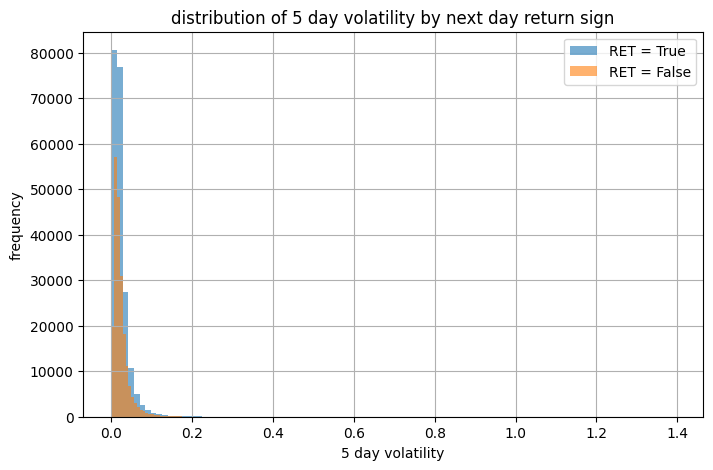

In [30]:
plt.figure(figsize=(8, 5))

df[df["RET"] == True]["VOLATILITY_5"].hist(
    bins=100, alpha=0.6, label="RET = True"
)
df[df["RET"] == False]["VOLATILITY_5"].hist(
    bins=100, alpha=0.6, label="RET = False"
)
plt.legend()
plt.title("distribution of 5 day volatility by next day return sign")
plt.xlabel("5 day volatility")
plt.ylabel("frequency")

- Both distributions are highly right skewed meaning most observations have low volatility

- we re gonna try to see if there's anay retuern behaviour if we split the data into low volatility medium & high volatility regimes

In [31]:
low_thr = df["VOLATILITY_5"].quantile(0.3)      # we create volatility regimes using quantiles
high_thr = df["VOLATILITY_5"].quantile(0.7)

def volatility_regime(v):
    if v <= low_thr:
        return "low volatility"
    elif v >= high_thr:
        return "high volatility"
    else:
        return "medium volatility"

df["VOL_REGIME"] = df["VOLATILITY_5"].apply(volatility_regime)

df["VOL_REGIME"].value_counts()     #  distribution of regimes


VOL_REGIME
medium volatility    168831
high volatility      124882
low volatility       124882
Name: count, dtype: int64

- Symmetric low & high regimes &medium regime larger  --> no bias --> we can compre regimes 
- let's see if the proba  of a + residual return change across volatility regimes or not 

In [32]:
regime_ret_proba = (
    df.groupby("VOL_REGIME")["RET"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

regime_ret_proba


,VOL_REGIME,RET,proportion
0,high volatility,False,0.515903
1,high volatility,True,0.484097
2,low volatility,True,0.517657
3,low volatility,False,0.482343
4,medium volatility,False,0.503971
5,medium volatility,True,0.496029


- the proba of a + residual return depends on the recent volatility regime
    - low volatility environments are slightly associated with + returns 
    -  high volatility environments exhibit  higher proba of - returns

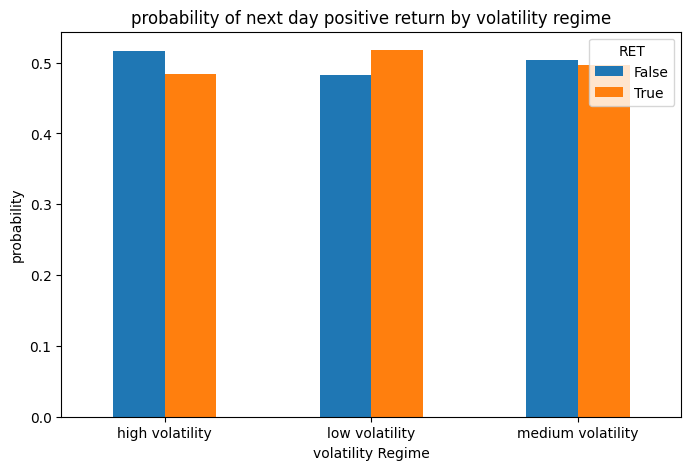

In [34]:
pivot = regime_ret_proba.pivot(
    index="VOL_REGIME", columns="RET", values="proportion"
)
pivot.plot(kind="bar", figsize=(8, 5))
plt.title("probability of next day positive return by volatility regime")
plt.ylabel("probability")
plt.xlabel("volatility Regime")
plt.xticks(rotation=0)
plt.legend(title="RET")

- volatility is not a direct predictor of returns  but it strongly conditions the probability distribution of future returns...


## Momentum × Volatility

we will see if  short term momentum behave differently in low vs high volatility regimes or not ? 

In [35]:
df.groupby(["VOL_REGIME", "RET"])["RET_mean_5"].describe() # mean short term momentum x volatility regime & target

count      mean       std       min       25%       50%       75%       max
VOL_REGIME        RET                                                                                 
high volatility   False  64427.0  0.002071  0.021082 -0.224653 -0.008536  0.002014  0.012690  0.331250
                  True   60455.0  0.001537  0.021474 -0.253899 -0.009438  0.001455  0.012453  0.604759
low volatility    False  60236.0  0.000465  0.005753 -0.065022 -0.002643  0.000511  0.003726  0.061516
                  True   64646.0  0.000474  0.005628 -0.065558 -0.002574  0.000510  0.003694  0.044053
medium volatility False  83964.0  0.000535  0.009241 -0.198527 -0.004769  0.000629  0.006015  0.136364
                  True   82611.0  0.000225  0.009198 -0.105263 -0.004947  0.000376  0.005667  0.091710

- high volatility regime: stronger recent momentum is actually associated with negative nextday returns
- low volatility regime: short term momentum carries  no directional information wich is normalm low volatility --> low opportunities

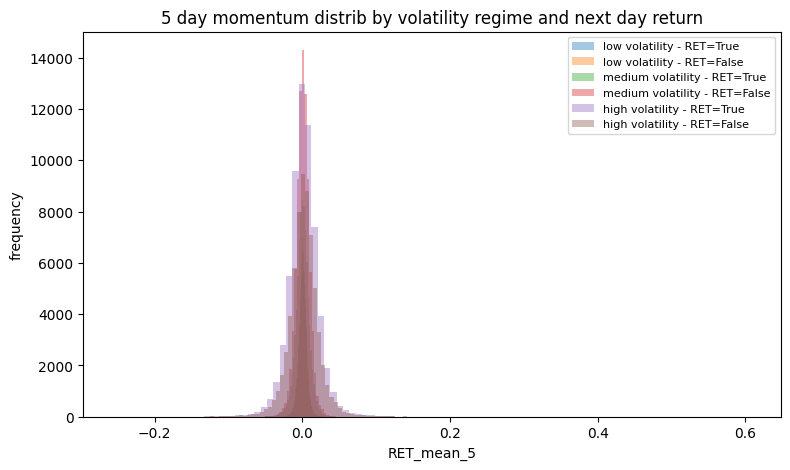

In [36]:
plt.figure(figsize=(9, 5))
for regime in ["low volatility", "medium volatility", "high volatility"]:
    subset_true = df[(df["VOL_REGIME"] == regime) & (df["RET"] == True)]["RET_mean_5"]
    subset_false = df[(df["VOL_REGIME"] == regime) & (df["RET"] == False)]["RET_mean_5"]

    plt.hist(subset_true, bins=100, alpha=0.4, label=f"{regime} - RET=True")
    plt.hist(subset_false, bins=100, alpha=0.4, label=f"{regime} - RET=False")

plt.legend(fontsize=8)
plt.title("5 day momentum distrib by volatility regime and next day return")
plt.xlabel("RET_mean_5")
plt.ylabel("frequency")
plt.show()

- Short term momentum exhibits regime dependent behavior
- In high volatility environments stronger recent momentum is associated with a higher probability of negative next day returns -->  mean-reversion effects under market stress
-  momentum carries little information in low volatility regimes

## CC: Linear models alone will struggle--> tree based models can learn this non linearity --> gradient boosting models (XGBoost / LightGBM) are the appropriate choice --> NN are not expected to add value dur to  the weak regime based signal and the lack of temporal structure...